In [6]:
# ========= Config =========
TREC_DL_YEAR = "2021"
MODEL = "llama3-8b-instruct"

LANGS = ["raw", "eng", "fr", "ru", "ar", "zh", "vi", "th", "sw", "ga", "hi"]
CRITERIA = ["topicality", "coverage", "exactness", "contextuality"]

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("././../../../").resolve()
VALID_LABELS = {0, 1, 2, 3}

# NOTE: your folder in the screenshot is "criteria_composed" (plural)
CRITERION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "llm_label"
    / f"trec_dl_{TREC_DL_YEAR}"
    / MODEL
    / "criteria_composed"
)

# include relevance too
CRITERIA = ["contextuality", "coverage", "exactness", "topicality", "relevance"]


def load_df_for_lang(lang: str) -> pd.DataFrame:
    """
    Read and concatenate part001..part005 for a language.
    Folder layout:
      .../criteria_composed/<lang>/<MODEL>_trecdl_<YEAR>_<lang>_criterion_cache_part00X.csv
    """
    lang_dir = CRITERION_DIR / lang
    if not lang_dir.exists():
        raise FileNotFoundError(f"Language dir not found: {lang_dir}")

    pattern = f"{MODEL}_trecdl_{TREC_DL_YEAR}_{lang}_criterion_cache_part*.csv"
    paths = sorted(lang_dir.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"No files matched: {lang_dir / pattern}")

    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["__source_file"] = p.name  # optional: helpful for debugging
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def load_lang_series(df: pd.DataFrame, criterion: str) -> pd.Series:
    """
    Pull valid labels from the column named exactly `criterion`.
    (You showed: contextuality, coverage, exactness, topicality, relevance)
    """
    if criterion not in df.columns:
        raise KeyError(f"Missing column '{criterion}'. cols={list(df.columns)}")

    s = df[criterion].astype(str).str.strip()
    s = s[s != ""]
    s = pd.to_numeric(s, errors="coerce").dropna()
    s = s[(s % 1 == 0)].astype(int)
    s = s[s.isin(VALID_LABELS)]
    return s


def mean_ci_95(series: pd.Series):
    x = series.to_numpy(dtype=float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan
    mu = float(np.mean(x))
    if n == 1:
        return mu, mu, mu
    se = float(np.std(x, ddof=1) / np.sqrt(n))
    z = 1.96
    return mu, mu - z * se, mu + z * se


rows = []

for lang in LANGS:
    try:
        df_lang = load_df_for_lang(lang)
    except Exception as e:
        for crit in CRITERIA:
            rows.append({
                "criterion": crit,
                "language": lang,
                "mean": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "n": 0,
                "error": str(e),
            })
        continue

    for crit in CRITERIA:
        try:
            s = load_lang_series(df_lang, crit)
            mu, lo, hi = mean_ci_95(s)
            rows.append({
                "criterion": crit,
                "language": lang,
                "mean": mu,
                "ci_low": lo,
                "ci_high": hi,
                "n": len(s),
            })
        except Exception as e:
            rows.append({
                "criterion": crit,
                "language": lang,
                "mean": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "n": 0,
                "error": str(e),
            })

summary = pd.DataFrame(rows)

display(summary)
display(summary.groupby("criterion")["n"].sum())

,criterion,language,mean,ci_low,ci_high,n
0,contextuality,raw,1.765762,1.725449,1.806075,2395
1,coverage,raw,1.857203,1.814613,1.899792,2395
2,exactness,raw,1.835073,1.793967,1.876179,2395
3,topicality,raw,2.284760,2.246509,2.323011,2395
4,relevance,raw,1.050939,1.009348,1.092531,2395
5,contextuality,eng,2.074482,2.032742,2.116222,1544
6,coverage,eng,2.269256,2.231782,2.306729,1545
7,exactness,eng,2.207767,2.167471,2.248063,1545
8,topicality,eng,2.681995,2.652083,2.711907,1544
9,relevance,eng,1.050939,1.009348,1.092531,2395


criterion
contextuality    23794
coverage         23795
exactness        22051
relevance        24645
topicality       21399
Name: n, dtype: int64

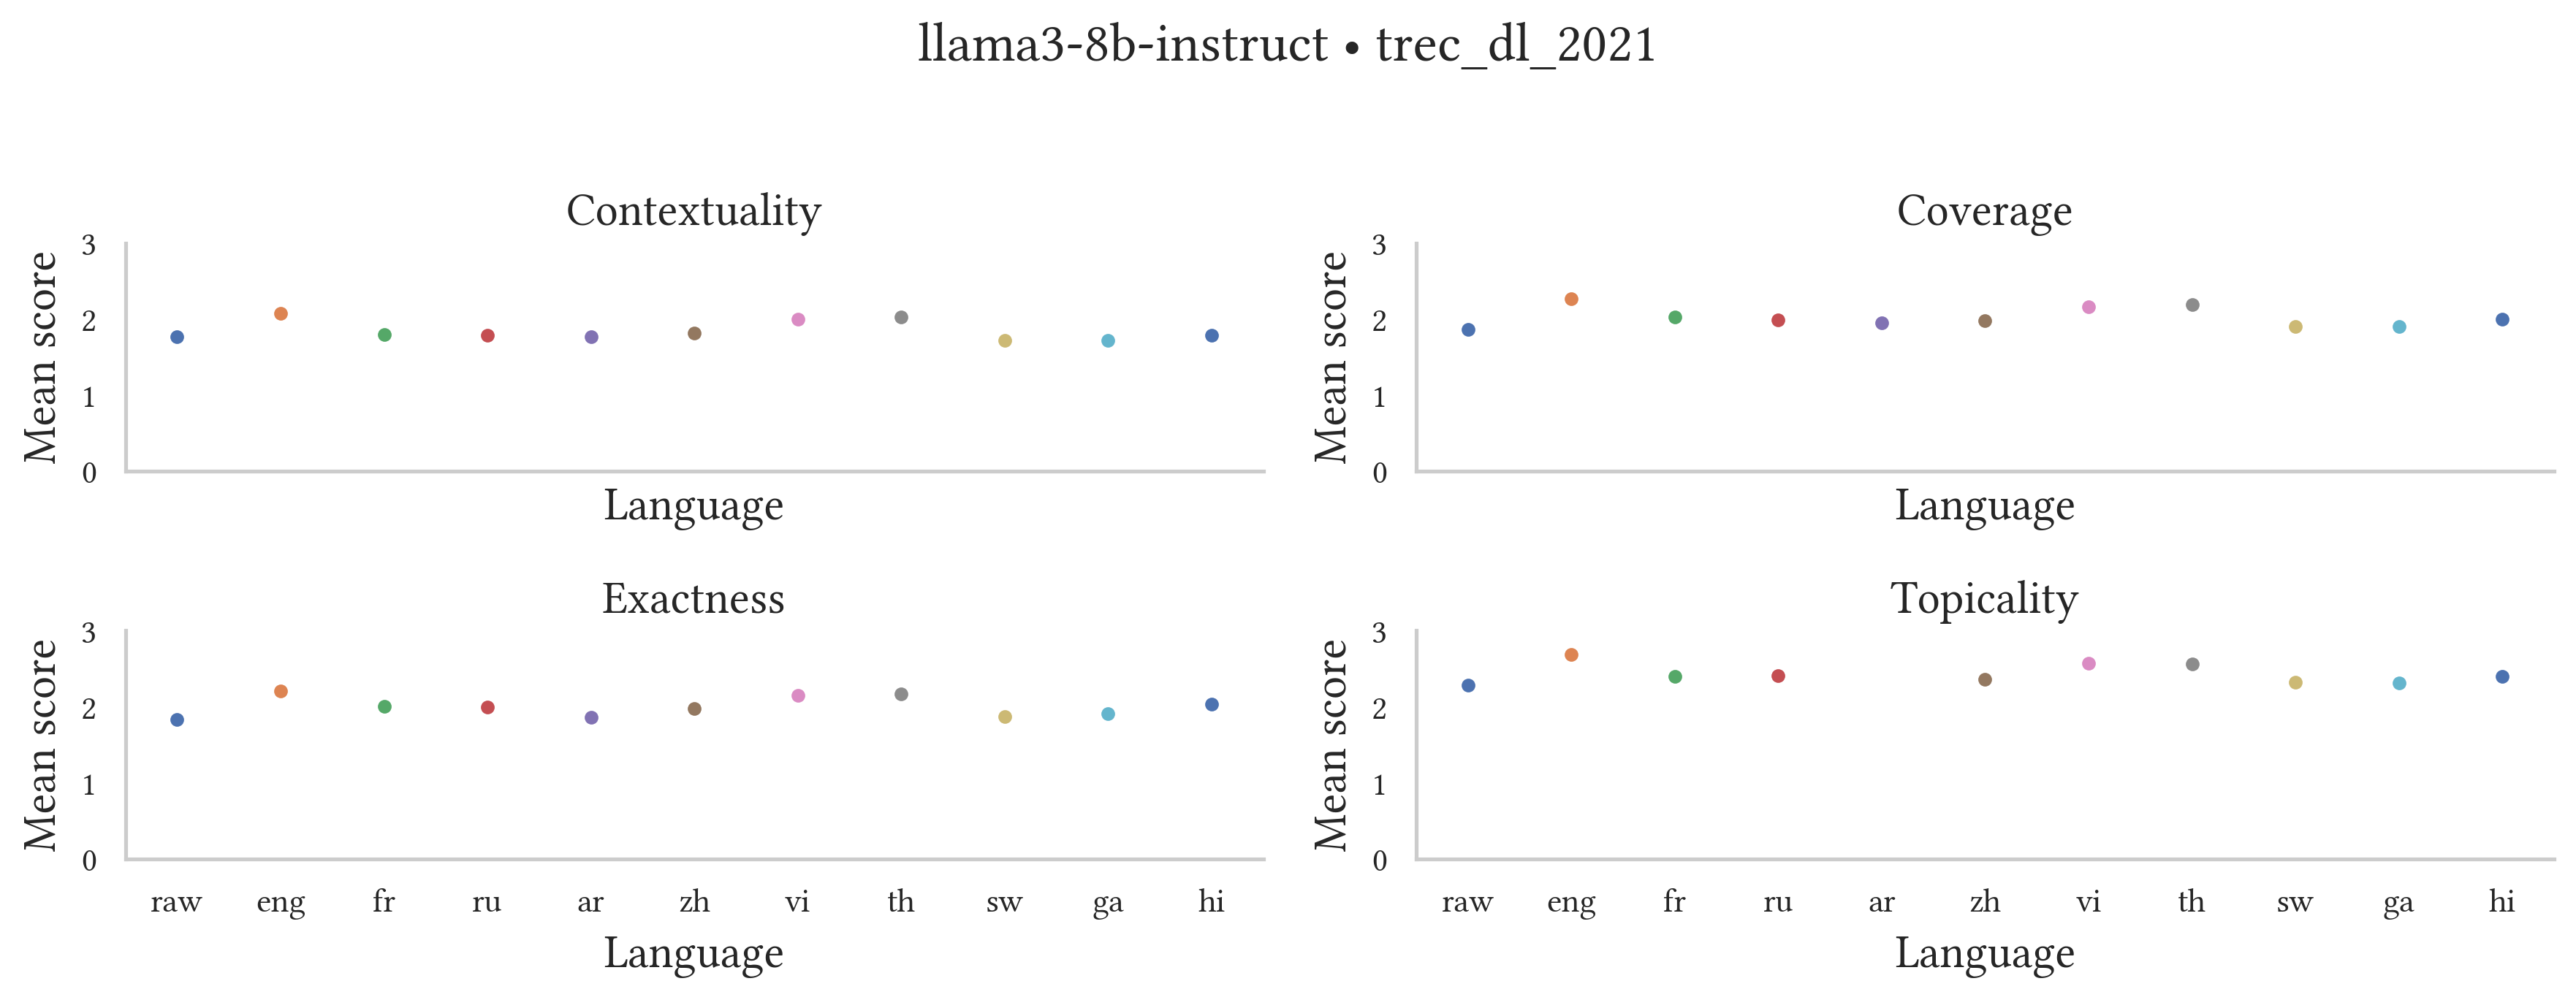

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import settings

settings.apply_paper_fmt()

def plot_paper_4panel(summary: pd.DataFrame, langs, criteria, title=None):
    langs = list(langs)

    # Use Matplotlib default cycle under your rcParams
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not colors:
        colors = ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    lang2color = {lang: colors[i % len(colors)] for i, lang in enumerate(langs)}

    # Override figsize for this multi-panel plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 4.5), sharex=True)
    axes = axes.ravel()

    for ax, crit in zip(axes, criteria):
        sub = summary[summary["criterion"] == crit].copy()
        sub["language"] = pd.Categorical(sub["language"], categories=langs, ordered=True)
        sub = sub.sort_values("language")

        x = np.arange(len(langs))
        y = sub["mean"].to_numpy(float)
        lo = sub["ci_low"].to_numpy(float)
        hi = sub["ci_high"].to_numpy(float)

        # asymmetric error bars
        yerr = np.vstack([y - lo, hi - y])

        # remove grid
        ax.grid(False)

        for i, lang in enumerate(langs):
            if np.isnan(y[i]):
                continue
            ax.errorbar(
                x[i], y[i],
                yerr=yerr[:, i].reshape(2, 1),
                fmt="o",
                linestyle="none",
                # horizontal caps at whisker ends
                capsize=6,
                capthick=1.5,
                elinewidth=1.5,
                markersize=4.5,
                markeredgewidth=0,
                color=lang2color[lang],
                ecolor=lang2color[lang],
            )
        ax.set_title(crit.capitalize())
        ax.set_xlabel("Language")
        ax.set_ylabel("Mean score")
        ax.set_xticks(x)
        ax.set_xticklabels(langs)

        # tight y limits (panel-specific)
        ok = ~np.isnan(y)
        if ok.any():
            ax.set_ylim(0, 3)
        # clean spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    if title:
        fig.suptitle(title, y=1.02)

    fig.tight_layout()
    plt.show()

plot_paper_4panel(
    summary,
    LANGS,
    CRITERIA,
    title=f"{MODEL} • trec_dl_{TREC_DL_YEAR}"
)

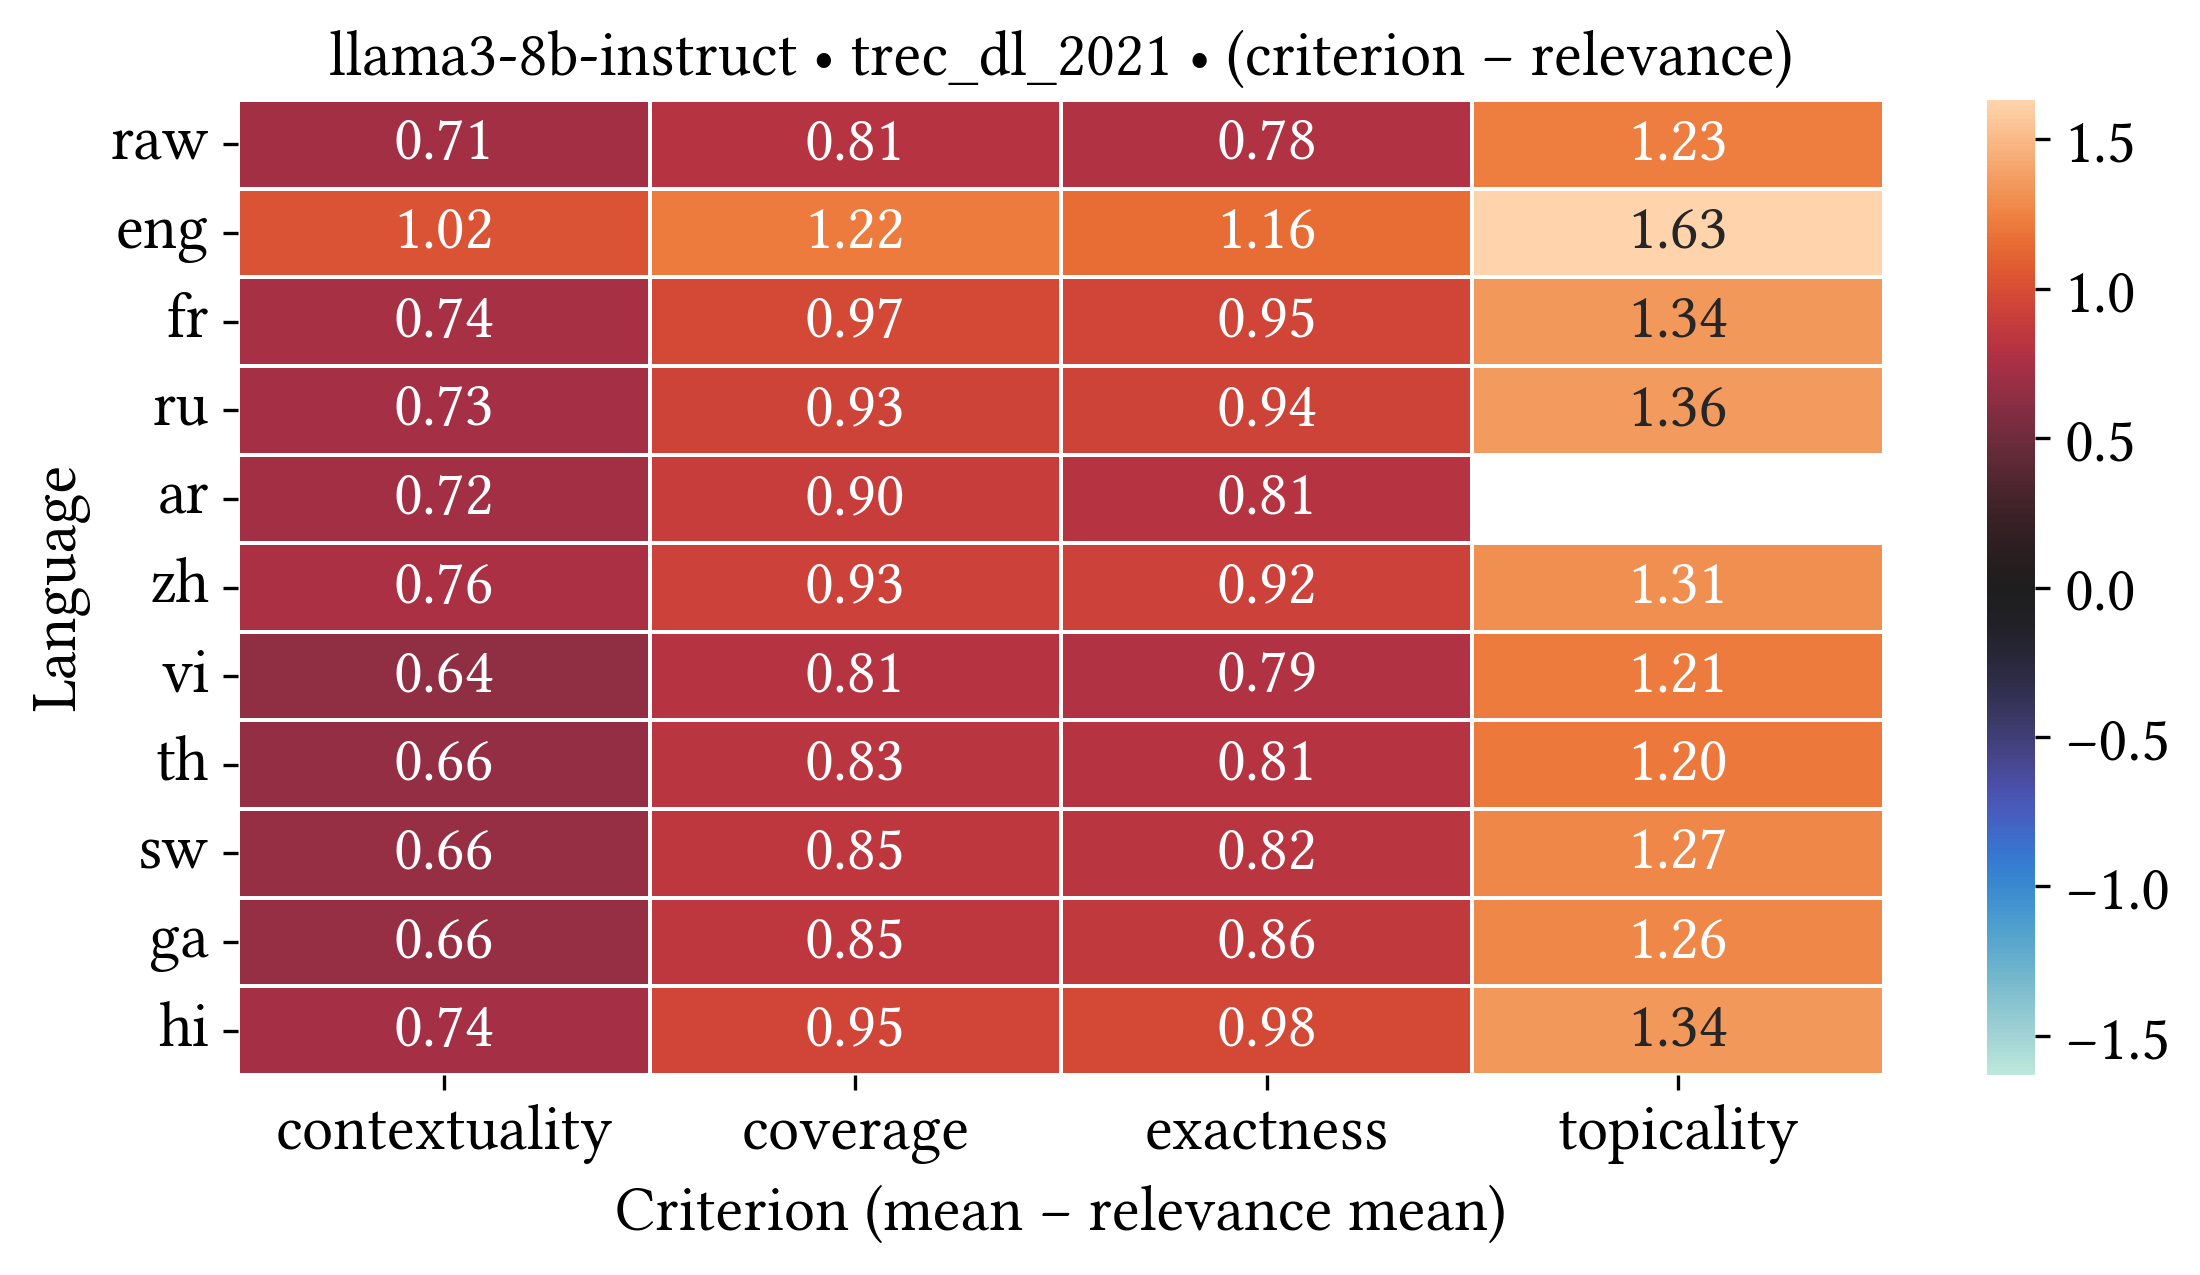

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import settings

settings.apply_paper_fmt()

def heatmap_criteria_minus_relevance(summary: pd.DataFrame, langs, criteria, title=None, annotate=True):
    langs = list(langs)
    criteria = [c for c in criteria if c != "relevance"]

    mat = summary.pivot(index="language", columns="criterion", values="mean").reindex(index=langs)

    if "relevance" not in mat.columns:
        raise KeyError("summary must include criterion='relevance' to compare against it.")

    rel = mat["relevance"]
    diff = mat[criteria].sub(rel, axis=0)  # criterion - relevance

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.grid(False)

    # symmetric color range around 0 for fair comparison
    vmax = np.nanmax(np.abs(diff.to_numpy()))
    vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1.0

    sns.heatmap(
        diff,
        ax=ax,
        annot=annotate,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        center=0.0,
        vmin=-vmax,
        vmax=vmax,
        cbar=True,
    )

    ax.set_ylabel("Language")
    ax.set_xlabel("Criterion (mean − relevance mean)")
    ax.set_title(title or "Criterion means compared to relevance (difference)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

heatmap_criteria_minus_relevance(
    summary,
    LANGS,
    criteria=["contextuality", "coverage", "exactness", "topicality"],  # no relevance here
    title=f"{MODEL} • trec_dl_{TREC_DL_YEAR} • (criterion − relevance)",
    annotate=True,
)